<a href="https://colab.research.google.com/github/Abidau/MachineLearning/blob/main/Kuis_244107020212_NaufalAbidAurizky.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **GABUNGAN NOTEBOOK: PREPROCESSING, K-MEANS, DAN DBSCAN**

Notebook ini adalah gabungan dari 7 bagian kode (hasil dari 5 file notebook). **Seluruh sel kode dan sel markdown asli disalin apa adanya tanpa diubah.** Hanya sel pembatas bagian (bertanda ▶▶▶) dan sel kesimpulan di akhir yang ditambahkan.

| No | Bagian | Sumber |
|---|---|---|
| 1 | Preprocessing | Preprocecing___Kmeans_Euclidean.ipynb |
| 2 | K-Means Euclidean | Preprocecing___Kmeans_Euclidean.ipynb |
| 3 | K-Means Manhattan | Kmeans_Manhattan___Kmeans_Cosine.ipynb |
| 4 | K-Means Cosine | Kmeans_Manhattan___Kmeans_Cosine.ipynb |
| 5 | DBSCAN Euclidean | DBscan_Euclidean.ipynb |
| 6 | DBSCAN Manhattan | DBscan_Manhattan.ipynb |
| 7 | DBSCAN Cosine | DBscan_Cosine.ipynb |

**Catatan:** bagian preprocessing identik di kelima file sehingga hanya dimasukkan satu kali (dari file Preprocecing___Kmeans_Euclidean). Bagian pengulangan (preprocessing + K-Means Euclidean) di dalam file DBSCAN Manhattan dan DBSCAN Cosine tidak dimasukkan lagi.

# **1. PEMAHAMAN DATA (Nuril_244107020004)**

### **1.1 Import Library**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)
import time

### **1.2 Membaca Dataset**

In [ ]:
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/Semester 5/PBL/jakarta_house.csv')


Mounted at /content/drive


### **1.3 Menampilkan Data**

In [ ]:
df.head()

,index,price,district,city,bed_rooms,bath_rooms,carport,land_area,building_area
0,1,5900000000,Citra Garden,Jakarta Barat,2,4,2,250.0,350.0
1,2,2700000000,Jelambar,Jakarta Barat,4,2,0,100.0,225.0
2,3,2200000000,Jelambar,Jakarta Barat,3,3,0,60.0,140.0
3,4,1900000000,Jelambar,Jakarta Barat,3,2,0,60.0,120.0
4,5,2100000000,Tanjung Duren,Jakarta Barat,4,3,0,56.0,108.0


### **1.4 Mengetahui Ukuran Dataset**

In [ ]:
print("Jumlah baris :", df.shape[0])
print("Jumlah kolom :", df.shape[1])

Jumlah baris : 10000
Jumlah kolom : 9


### **1.5 Menampilkan Nama Kolom**

In [ ]:
print('===Nama Kolom===')
for col in df.columns:
    print(col)

===Nama Kolom===
index
price
district
city
bed_rooms
bath_rooms
carport
land_area
building_area


### **1.6 Mengecek Tipe Data**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   index          10000 non-null  int64  
 1   price          10000 non-null  int64  
 2   district       10000 non-null  object 
 3   city           10000 non-null  object 
 4   bed_rooms      10000 non-null  int64  
 5   bath_rooms     10000 non-null  int64  
 6   carport        10000 non-null  int64  
 7   land_area      9997 non-null   float64
 8   building_area  9995 non-null   float64
dtypes: float64(2), int64(5), object(2)
memory usage: 703.3+ KB


### **1.7 Mengecek Missing Value**

In [ ]:
df.isnull().sum()

,0
index,0
price,0
district,0
city,0
bed_rooms,0
bath_rooms,0
carport,0
land_area,3
building_area,5


### **Mengecek Data Duplikat**

In [ ]:
df.duplicated().sum()

print("Jumlah data duplikat :", df.duplicated().sum())

Jumlah data duplikat : 0


# **2. EXPLORATORY DATA ANALYSIS (Nuril_244107020004)**

### **2.1 Statistik Deskriptifk**

In [ ]:
df.describe()

,index,price,bed_rooms,bath_rooms,carport,land_area,building_area
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,9997.000000,9995.000000
mean,5000.50000,1.004029e+10,4.253500,3.521300,1.578900,296.610183,319.962481
std,2886.89568,2.004519e+10,3.176609,2.900136,1.743467,502.921686,357.676034
min,1.00000,1.850000e+06,0.000000,0.000000,0.000000,1.000000,1.000000
25%,2500.75000,2.500000e+09,3.000000,2.000000,1.000000,100.000000,139.000000
50%,5000.50000,4.500000e+09,4.000000,3.000000,1.000000,177.000000,230.000000
75%,7500.25000,9.800000e+09,5.000000,4.000000,2.000000,335.000000,400.000000
max,10000.00000,9.000000e+11,63.000000,63.000000,31.000000,17714.000000,15331.000000


### **2.2 Analisis Distribusi Data**

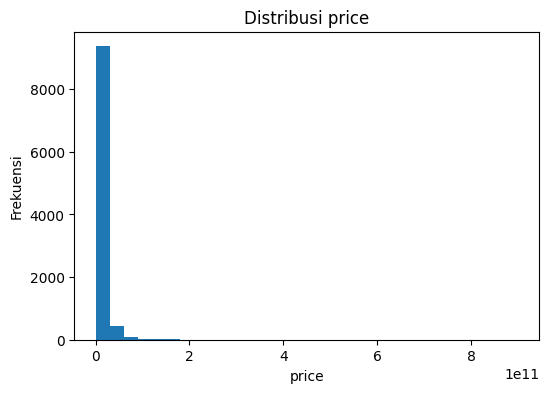

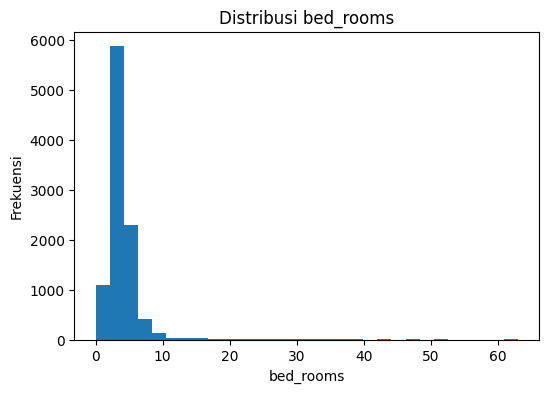

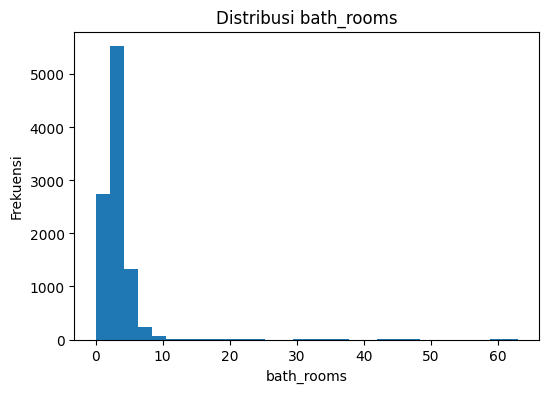

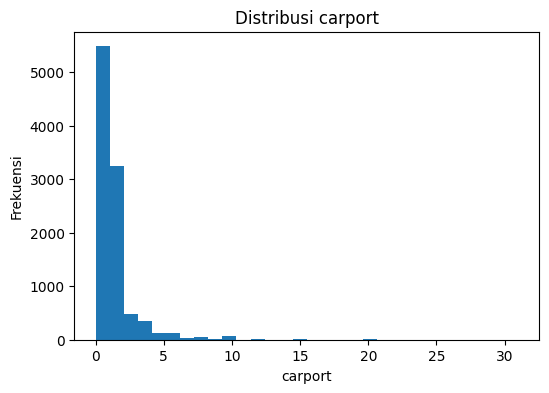

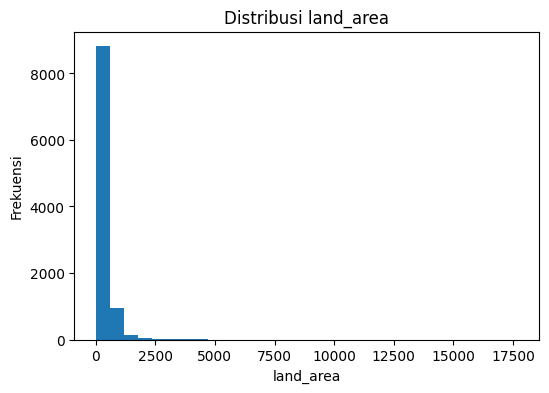

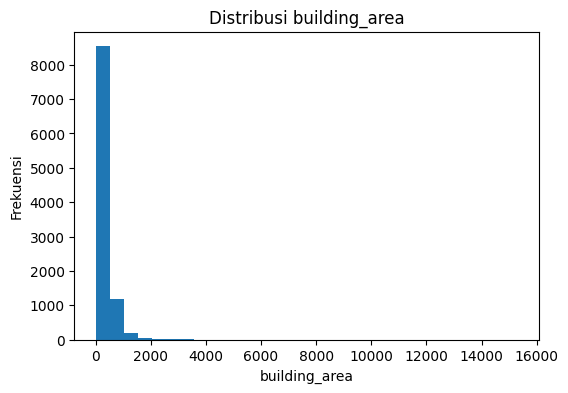

In [ ]:
num_cols = [
    'price',
    'bed_rooms',
    'bath_rooms',
    'carport',
    'land_area',
    'building_area'
]

for col in num_cols:
    plt.figure(figsize=(6,4))
    plt.hist(df[col], bins=30)
    plt.title(f'Distribusi {col}')
    plt.xlabel(col)
    plt.ylabel('Frekuensi')
    plt.show()

### **2.3 Korelasi Antar Fitur**

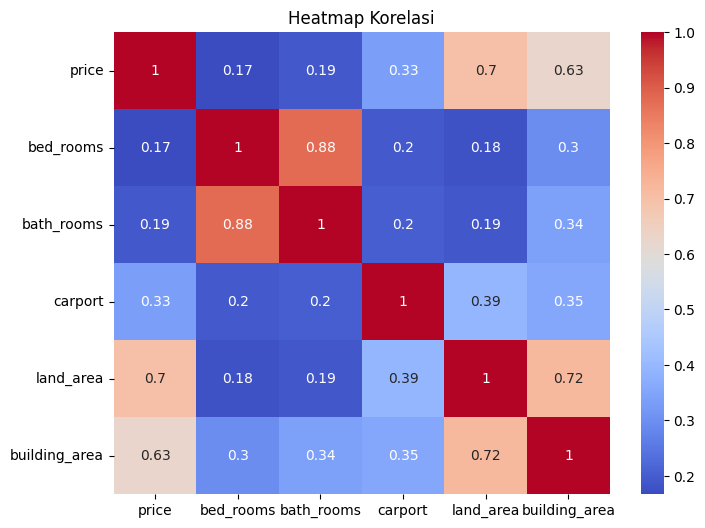

In [ ]:
corr = df[num_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title('Heatmap Korelasi')
plt.show()

# **3. PRA PENGOLAHAN DATA (Nuril_244107020004)**

### **3.1 Data Imputation / Mengisi Missing Value**

In [ ]:
# Land Area - Mean
df['land_area'] = df['land_area'].fillna(df['land_area'].mean())

# Building Area - Mean
df['building_area'] = df['building_area'].fillna(df['building_area'].mean())



### **3.2 Validasi Hasil Imputasi**

In [ ]:
df.info()

print()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   index          10000 non-null  int64  
 1   price          10000 non-null  int64  
 2   district       10000 non-null  object 
 3   city           10000 non-null  object 
 4   bed_rooms      10000 non-null  int64  
 5   bath_rooms     10000 non-null  int64  
 6   carport        10000 non-null  int64  
 7   land_area      10000 non-null  float64
 8   building_area  10000 non-null  float64
dtypes: float64(2), int64(5), object(2)
memory usage: 703.3+ KB



,0
index,0
price,0
district,0
city,0
bed_rooms,0
bath_rooms,0
carport,0
land_area,0
building_area,0


### **3.3 Deteksi Outlier**

In [ ]:
# Menyimpan batas IQR awal
batas_iqr = {}

# Menentukan Kolom Numerik
num_cols = [
    'price',
    'bed_rooms',
    'bath_rooms',
    'carport',
    'land_area',
    'building_area'
]

# Menghitung Nilai Q1, Q3, IQR, Batas Outlier, dan Jumlah Outlier
for col in num_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    batas_bawah = Q1 - (1.5 * IQR)
    batas_atas = Q3 + (1.5 * IQR)

    # Simpan batas awal
    batas_iqr[col] = {
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'bawah': batas_bawah,
        'atas': batas_atas
    }

    jumlah_outlier = df[
        (df[col] < batas_bawah) |
        (df[col] > batas_atas)
    ].shape[0]

    print(f"\n===== {col} =====")
    print("Q1 :", Q1)
    print("Q3 :", Q3)
    print("IQR :", IQR)
    print("Batas Bawah :", batas_bawah)
    print("Batas Atas :", batas_atas)
    print("Jumlah Outlier :", jumlah_outlier)


===== price =====
Q1 : 2500000000.0
Q3 : 9800000000.0
IQR : 7300000000.0
Batas Bawah : -8450000000.0
Batas Atas : 20750000000.0
Jumlah Outlier : 1107

===== bed_rooms =====
Q1 : 3.0
Q3 : 5.0
IQR : 2.0
Batas Bawah : 0.0
Batas Atas : 8.0
Jumlah Outlier : 308

===== bath_rooms =====
Q1 : 2.0
Q3 : 4.0
IQR : 2.0
Batas Bawah : -1.0
Batas Atas : 7.0
Jumlah Outlier : 270

===== carport =====
Q1 : 1.0
Q3 : 2.0
IQR : 1.0
Batas Bawah : -0.5
Batas Atas : 3.5
Jumlah Outlier : 795

===== land_area =====
Q1 : 100.0
Q3 : 335.0
IQR : 235.0
Batas Bawah : -252.5
Batas Atas : 687.5
Jumlah Outlier : 881

===== building_area =====
Q1 : 139.0
Q3 : 400.0
IQR : 261.0
Batas Bawah : -252.5
Batas Atas : 791.5
Jumlah Outlier : 656


### **3.4 Penanganan Outlier**

In [ ]:
# Menyimpan jumlah data awal
jumlah_awal = len(df)

mask_outlier = pd.Series(False, index=df.index)

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    batas_bawah = Q1 - (1.5 * IQR)
    batas_atas = Q3 + (1.5 * IQR)

    mask_outlier |= (
        (df[col] < batas_bawah) |
        (df[col] > batas_atas)
    )

df = df[~mask_outlier]

print("Jumlah data sebelum :", jumlah_awal)
print("Jumlah data sesudah :", len(df))
print("Data yang terhapus :", jumlah_awal - len(df))

Jumlah data sebelum : 10000
Jumlah data sesudah : 8001
Data yang terhapus : 1999


### **3.5 Validasi Hasil Penanganan Outlier**

In [ ]:
# Mengecek Jumlah Data Setelah Penghapusan
for col in num_cols:

    batas_bawah = batas_iqr[col]['bawah']
    batas_atas = batas_iqr[col]['atas']

    jumlah_outlier = df[
        (df[col] < batas_bawah) |
        (df[col] > batas_atas)
    ].shape[0]

    print(f"{col} : {jumlah_outlier}")


price : 0
bed_rooms : 0
bath_rooms : 0
carport : 0
land_area : 0
building_area : 0


### **3.6 Visualisasi Distribusi Data Setelah Penghapusan Outlier**

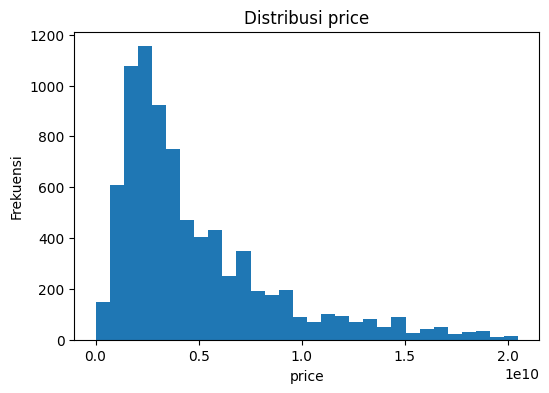

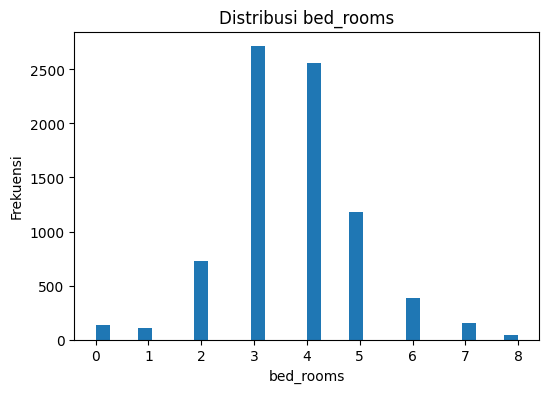

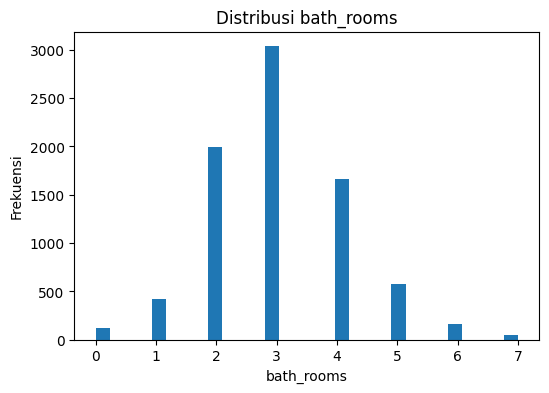

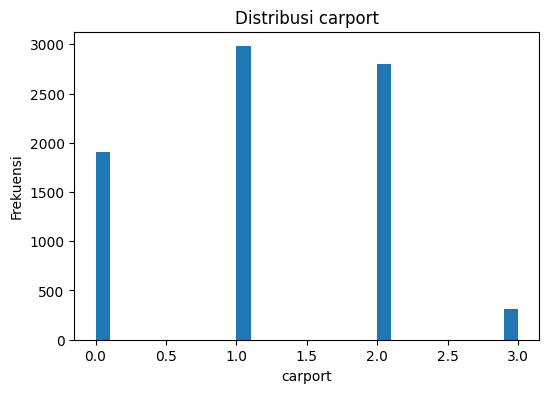

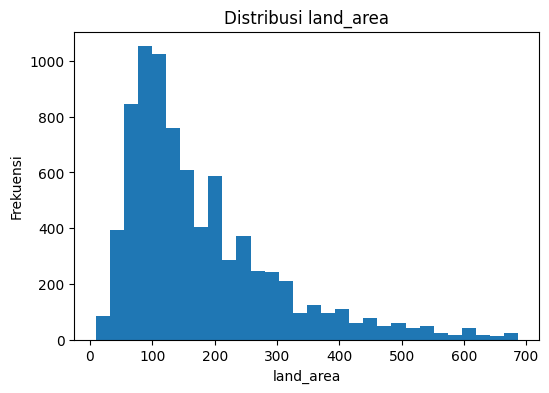

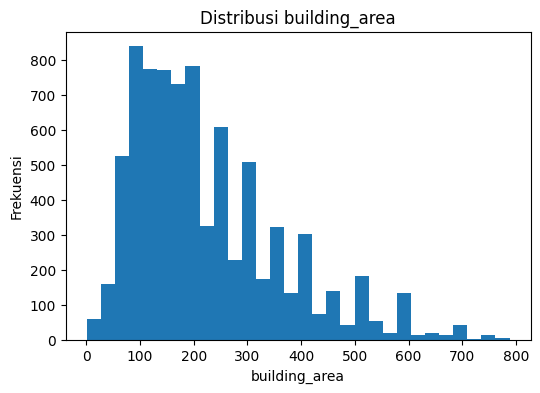

In [ ]:
num_cols = [
    'price',
    'bed_rooms',
    'bath_rooms',
    'carport',
    'land_area',
    'building_area'
]

for col in num_cols:
    plt.figure(figsize=(6,4))
    plt.hist(df[col], bins=30)
    plt.title(f'Distribusi {col}')
    plt.xlabel(col)
    plt.ylabel('Frekuensi')
    plt.show()

### **3.7 Seleksi Fitur**

In [ ]:
df = df[
    [
        'price',
        'district',
        'city',
        'bed_rooms',
        'bath_rooms',
        'carport',
        'land_area',
        'building_area'
    ]
]

df.head()

,price,district,city,bed_rooms,bath_rooms,carport,land_area,building_area
0,5900000000,Citra Garden,Jakarta Barat,2,4,2,250.0,350.0
1,2700000000,Jelambar,Jakarta Barat,4,2,0,100.0,225.0
2,2200000000,Jelambar,Jakarta Barat,3,3,0,60.0,140.0
3,1900000000,Jelambar,Jakarta Barat,3,2,0,60.0,120.0
4,2100000000,Tanjung Duren,Jakarta Barat,4,3,0,56.0,108.0


### **3.8 Encoding data kategorikal**

In [ ]:
le = LabelEncoder()

# District
df['district'] = le.fit_transform(df['district'])

# City
df['city'] = le.fit_transform(df['city'])

### **3.9 Verifikasi Hasil Encoding**

In [ ]:
df[['district', 'city']].head()

,district,city
0,37,0
1,70,0
2,70,0
3,70,0
4,224,0


### **3.10 Standarisasi**

In [ ]:
scaler = StandardScaler()

df = pd.DataFrame(scaler.fit_transform(df),columns=df.columns)


print("================ Hasil Setelah Standardisasi ================")
df.head()

================ Hasil Setelah Standardisasi ================


,price,district,city,bed_rooms,bath_rooms,carport,land_area,building_area
0,0.289543,-1.108788,-1.292805,-1.344695,0.832897,0.961320,0.589494,0.909454
1,-0.546548,-0.624150,-1.292805,0.240761,-0.888402,-1.413706,-0.643029,0.006448
2,-0.677188,-0.624150,-1.292805,-0.551967,-0.027752,-1.413706,-0.971701,-0.607597
3,-0.755571,-0.624150,-1.292805,-0.551967,-0.888402,-1.413706,-0.971701,-0.752078
4,-0.703315,1.637498,-1.292805,0.240761,-0.027752,-1.413706,-1.004569,-0.838766


# **4. MENENTUKAN JUMLAH CLUSTER (Nuril_244107020004)**

### **4.1 Metode Elbow**

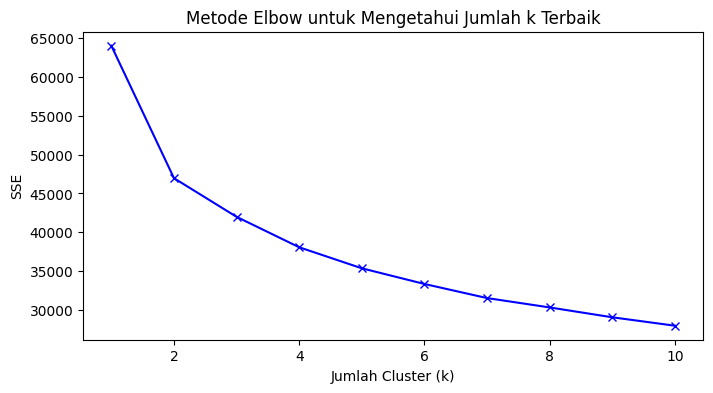

In [ ]:
# List nilai SSE
sse = []

# Cari k terbaik dari 1-10
K = range(1, 11)

# Cek nilai SSE setiap k
for k in K:
 kmeanModel = KMeans(
     n_clusters=k,
     random_state=42
     )
 kmeanModel.fit(df)
 sse.append(kmeanModel.inertia_)

# Plotting SSE
plt.figure(figsize=(8,4))
plt.plot(K, sse, 'bx-')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('SSE')
plt.title('Metode Elbow untuk Mengetahui Jumlah k Terbaik')
plt.show()

### **Menampilkan Nilai SSE Setiap k**

In [ ]:
for k, nilai_sse in zip(K, sse):
    print(f'k = {k}, SSE = {nilai_sse:.2f}')

k = 1, SSE = 64008.00
k = 2, SSE = 46967.64
k = 3, SSE = 41992.01
k = 4, SSE = 38076.66
k = 5, SSE = 35370.87
k = 6, SSE = 33353.93
k = 7, SSE = 31539.28
k = 8, SSE = 30335.91
k = 9, SSE = 29067.16
k = 10, SSE = 27983.70


### **Evaluasi Jumlah Cluster Menggunakan Silhouette Score**

In [ ]:
for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42
        )

    labels = kmeans.fit_predict(df)

    score = silhouette_score(
        df,
        labels
    )

    print(f'k = {k}, silhouette = {score:.4f}')

k = 2, silhouette = 0.2724
k = 3, silhouette = 0.1627
k = 4, silhouette = 0.1467
k = 5, silhouette = 0.1588
k = 6, silhouette = 0.1515
k = 7, silhouette = 0.1535
k = 8, silhouette = 0.1518
k = 9, silhouette = 0.1465
k = 10, silhouette = 0.1517


Berdasarkan hasil perhitungan Silhouette Score untuk nilai k = 2 sampai k = 10, diperoleh nilai Silhouette Score tertinggi pada k = 2 yaitu sebesar 0,2724. Nilai ini lebih tinggi dibandingkan nilai k lainnya, sehingga menunjukkan bahwa pembagian data menjadi 2 cluster menghasilkan kualitas cluster yang paling baik. Oleh karena itu, jumlah cluster optimal yang digunakan pada penelitian ini adalah 2 cluster.

# **5. KMEANS - EUCLIDEAN DISTANCE (Nuril_244107020004)**

## **5.1 Visualisasi Data Awal**

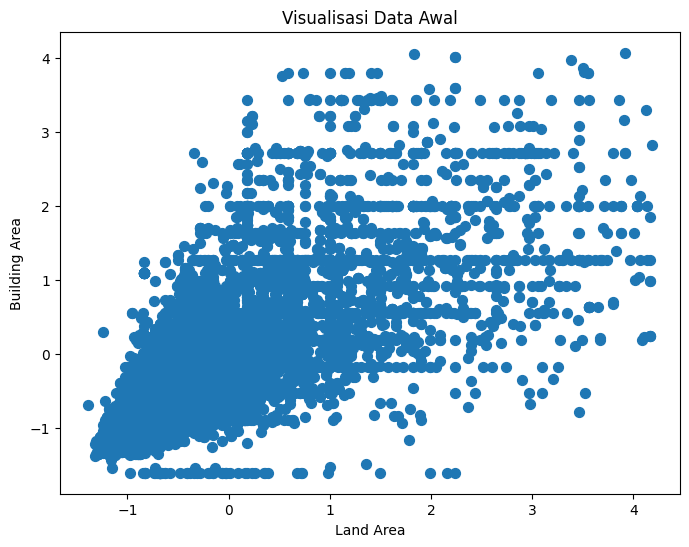

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    df['land_area'],
    df['building_area'],
    s=50
)

plt.xlabel('Land Area')
plt.ylabel('Building Area')
plt.title('Visualisasi Data Awal')

plt.show()

### **5.2 Model K-Means (Library)**

In [ ]:
start_time_kmeans_library = time.time()

# Inisiasi Model
cl_kmeans = KMeans(
    n_clusters=2,
    random_state=42
)

# Fit dan Predict
y_kmeans = cl_kmeans.fit_predict(df)

end_time_kmeans_library = time.time()

### **5.3 Model KMeans Euclidean Distance (Manual)**

In [ ]:
start_time_kmeans_manual = time.time()

# Ubah dataframe menjadi array numpy
X = df.values

# Jumlah cluster
k = 2

# Random centroid awal
np.random.seed(42)
random_index = np.random.choice(len(X), k, replace=False)
centroids = X[random_index]

max_iter = 100

for iteration in range(max_iter):
    # Hitung jarak euclidean
    distances = []

    for data in X:

        jarak_ke_centroid = []

        for centroid in centroids:

            jumlah = 0

            for i in range(len(data)):
                jumlah += (data[i] - centroid[i]) ** 2

            euclidean = jumlah ** 0.5

            jarak_ke_centroid.append(euclidean)

        distances.append(jarak_ke_centroid)

    distances = np.array(distances)

    # Tentukan cluster
    labels = np.argmin(distances, axis=1)

    # Hitung centroid baru
    new_centroids = []

    for cluster in range(k):

        anggota_cluster = X[labels == cluster]

        centroid_baru = anggota_cluster.mean(axis=0)

        new_centroids.append(centroid_baru)

    new_centroids = np.array(new_centroids)

    # Cek konvergen
    if np.allclose(centroids, new_centroids):
        print(f'Konvergen pada iterasi ke-{iteration+1}')
        break

    centroids = new_centroids

# Hasil akhir
y_kmeans_manual = labels

labels_asli = labels.copy()

# Membalik label agar sama dengan hasil library
y_kmeans_manual = 1 - y_kmeans_manual

print("Centroid Akhir")
print(centroids)

end_time_kmeans_manual = time.time()

Konvergen pada iterasi ke-18
Centroid Akhir
[[-0.48256004 -0.07171926 -0.06258127 -0.34915587 -0.34107299 -0.15641574
  -0.47102276 -0.50327387]
 [ 1.04896035  0.15589906  0.13603544  0.75897428  0.74140419  0.34000724
   1.02388128  1.09398684]]


### **5.4 Visualisasi Hasil Clustering**

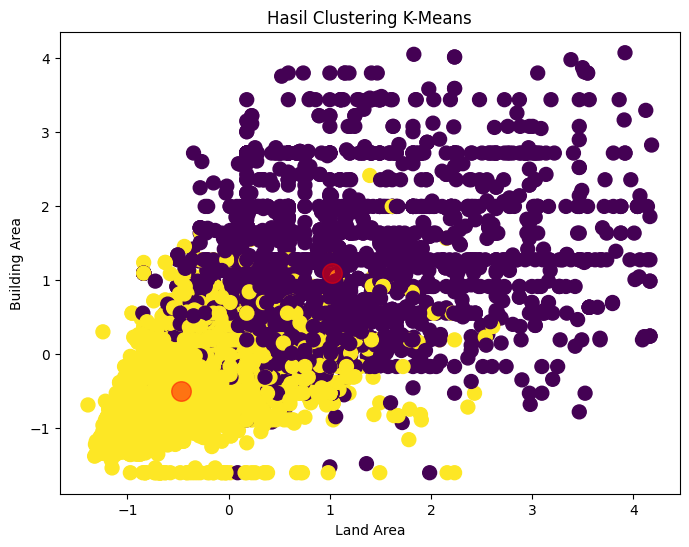

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    df['land_area'],
    df['building_area'],
    s=100,
    c=y_kmeans
)

# Centroid
centers = cl_kmeans.cluster_centers_

plt.scatter(
    centers[:, 6],
    centers[:, 7],
    c='red',
    s=200,
    alpha=0.5
)

plt.xlabel('Land Area')
plt.ylabel('Building Area')
plt.title('Hasil Clustering K-Means')

plt.show()

### **5.5 Visualisasi Hasil Clustering (Manual)**

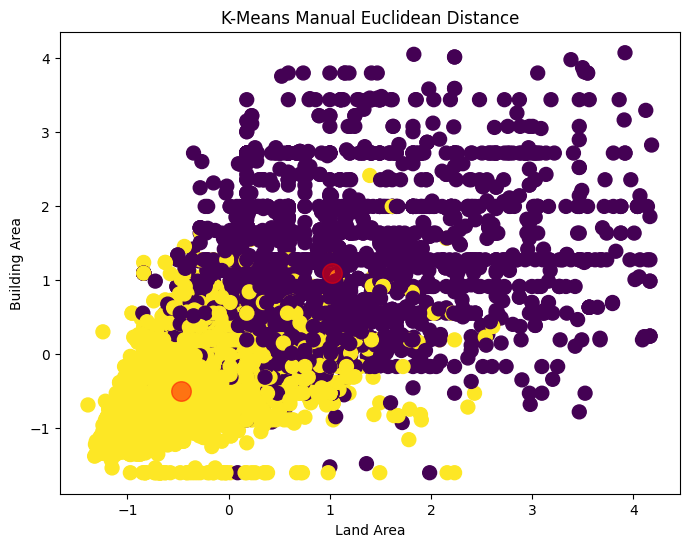

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    df['land_area'],
    df['building_area'],
    s=100,
    c=y_kmeans_manual
)

plt.scatter(
    centroids[:, 6],
    centroids[:, 7],
    c='red',
    s=200,
    alpha=0.5
)

plt.xlabel('Land Area')
plt.ylabel('Building Area')
plt.title('K-Means Manual Euclidean Distance')

plt.show()

### **5.4 Evaluasi Kmeans (Library)**

In [ ]:
silhouette = silhouette_score(df, y_kmeans)

dbi = davies_bouldin_score(df, y_kmeans)

chi = calinski_harabasz_score(df, y_kmeans)

execution_time = end_time_kmeans_library - start_time_kmeans_library

iterations = cl_kmeans.n_iter_

sse = cl_kmeans.inertia_

### **5.5 Evaluasi Kmeans (Manual)**

In [ ]:
silhouette_manual = silhouette_score(df,y_kmeans_manual)

dbi_manual = davies_bouldin_score(df,y_kmeans_manual)

chi_manual = calinski_harabasz_score(df,y_kmeans_manual)

execution_time_manual = end_time_kmeans_manual - start_time_kmeans_manual

iterations_manual = iteration + 1

sse_manual = 0

for i in range(len(X)):
    cluster = labels_asli[i]

    sse_manual += np.sum(
        (X[i] - centroids[cluster]) ** 2)


In [ ]:
hasil = pd.DataFrame({
    'Metode': ['K-Means Library', 'K-Means Manual'],
    'Silhouette': [silhouette, silhouette_manual],
    'DBI': [dbi, dbi_manual],
    'CHI': [chi, chi_manual],
    'Execution Time': [
        execution_time,
        execution_time_manual
    ],
    'Iterations': [
        iterations,
        iterations_manual
    ],
    'SSE': [
        sse,
        sse_manual
    ]
})
print("=" * 80)
print("TABEL EVALUASI K-MEANS EUCLIDEAN")
print("=" * 80)


print(hasil.to_string(index=False))

TABEL EVALUASI K-MEANS EUCLIDEAN
         Metode  Silhouette      DBI         CHI  Execution Time  Iterations          SSE
K-Means Library    0.272434 1.545718 2902.126109        0.010245           7 46967.644620
 K-Means Manual    0.272473 1.545588 2902.129714        2.626473          18 46967.608443


---
# **5. KMEANS - MANHATTAN DISTANCE (Hanif_244107020232)**

### **5.1 Implementasi Kelas Custom KMeans Manhattan**

Pada K-Means dengan Jarak Manhattan ($L_1$), fungsi objektif error yang diminimalkan adalah Sum of Absolute Errors (SAE) / Sum of Manhattan Distances, dan pembaruan centroid menggunakan nilai median.

In [ ]:
# ==========================================================
# 5.1 Implementasi Algoritma K-Means Manhattan (L1 Distance)
# ==========================================================
class KMeansManhattan:
    def __init__(self, n_clusters=2, max_iter=100, random_state=42):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.random_state = random_state

    def fit(self, X):
        np.random.seed(self.random_state)
        n_samples, n_features = X.shape
        initial_indices = np.random.choice(n_samples, self.n_clusters, replace=False)
        self.cluster_centers_ = X[initial_indices].copy()

        for _ in range(self.max_iter):
            # Hitung jarak Manhattan (|x - c|)
            distances = np.sum(np.abs(X[:, np.newaxis, :] - self.cluster_centers_[np.newaxis, :, :]), axis=2)
            labels = np.argmin(distances, axis=1)

            # Update centroid menggunakan median (optimal untuk L1)
            new_centers = np.array([
                np.median(X[labels == k], axis=0) if np.sum(labels == k) > 0 else self.cluster_centers_[k]
                for k in range(self.n_clusters)
            ])

            if np.allclose(self.cluster_centers_, new_centers, atol=1e-4):
                break
            self.cluster_centers_ = new_centers

        self.labels_ = labels
        # Hitung SAE (Sum of Absolute Errors) sebagai inertia Manhattan
        min_dist = np.min(distances, axis=1)
        self.inertia_ = np.sum(min_dist)
        return self

    def fit_predict(self, X):
        self.fit(X)
        return self.labels_

### **5.2 Metode Elbow (K-Means Manhattan)**

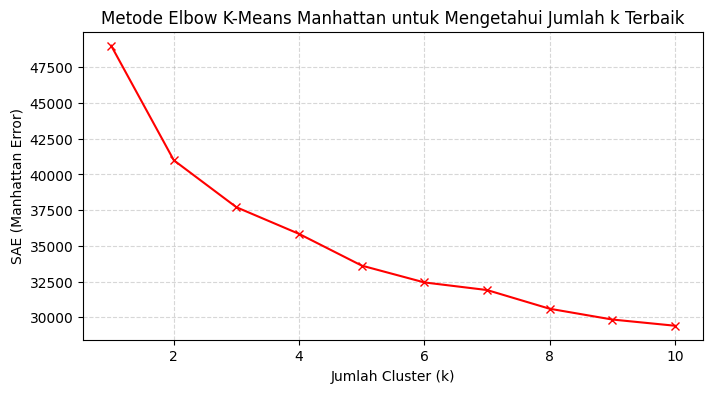

In [ ]:
X = df.values

# List nilai SAE (Sum of Absolute Errors)
sae_manhattan = []
K = range(1, 11)

for k in K:
    kmean_m = KMeansManhattan(n_clusters=k, random_state=42)
    kmean_m.fit(X)
    sae_manhattan.append(kmean_m.inertia_)

# Plotting Elbow
plt.figure(figsize=(8, 4))
plt.plot(K, sae_manhattan, 'rx-')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('SAE (Manhattan Error)')
plt.title('Metode Elbow K-Means Manhattan untuk Mengetahui Jumlah k Terbaik')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### **5.3 Menampilkan Nilai SAE Setiap k (Manhattan)**

In [ ]:
for k, nilai_sae in zip(K, sae_manhattan):
    print(f'k = {k}, SAE = {nilai_sae:.2f}')

k = 1, SAE = 49009.10
k = 2, SAE = 40991.70
k = 3, SAE = 37704.94
k = 4, SAE = 35840.82
k = 5, SAE = 33622.65
k = 6, SAE = 32445.16
k = 7, SAE = 31912.88
k = 8, SAE = 30604.68
k = 9, SAE = 29849.10
k = 10, SAE = 29415.25


### **5.4 Evaluasi Jumlah Cluster Menggunakan Silhouette Score (Manhattan)**

In [ ]:
for k in range(2, 11):
    km_m = KMeansManhattan(n_clusters=k, random_state=42)
    labels = km_m.fit_predict(X)
    score = silhouette_score(X, labels, metric='manhattan')
    print(f'k = {k}, silhouette (manhattan) = {score:.4f}')

k = 2, silhouette (manhattan) = 0.2920
k = 3, silhouette (manhattan) = 0.1569
k = 4, silhouette (manhattan) = 0.1378
k = 5, silhouette (manhattan) = 0.1511
k = 6, silhouette (manhattan) = 0.1450
k = 7, silhouette (manhattan) = 0.1411
k = 8, silhouette (manhattan) = 0.1481
k = 9, silhouette (manhattan) = 0.1558
k = 10, silhouette (manhattan) = 0.1451


### **5.5 Kesimpulan & Training Model Final (k = 2)**

In [ ]:
# Training model final dengan k optimal = 2
kmeans_manhattan = KMeansManhattan(n_clusters=2, random_state=42)
labels_manhattan = kmeans_manhattan.fit_predict(X)

sil_manhattan = silhouette_score(X, labels_manhattan, metric='manhattan')
db_manhattan = davies_bouldin_score(X, labels_manhattan)

print("=== HASIL FINAL K-MEANS MANHATTAN (k=2) ===")
print("Distribusi data per cluster :", np.bincount(labels_manhattan))
print(f"Silhouette Score (Manhattan) : {sil_manhattan:.4f}")
print(f"Davies-Bouldin Index         : {db_manhattan:.4f}")

=== HASIL FINAL K-MEANS MANHATTAN (k=2) ===
Distribusi data per cluster : [5000 3001]
Silhouette Score (Manhattan) : 0.2920
Davies-Bouldin Index         : 1.6472


Berdasarkan perhitungan Silhouette Score berbasis jarak Manhattan untuk rentang $k = 2$ hingga $k = 10$, nilai Silhouette Score tertinggi dicapai pada $k = 2$ yaitu sebesar 0.2920. Oleh karena itu, jumlah klaster optimal untuk K-Means Manhattan adalah 2 klaster.

---
# **KMEANS - COSINE DISTANCE (Hanif_244107020232)**

Untuk K-Means berbasis Cosine (Spherical K-Means), vektor data dinormalisasi secara $L_2$ (normalize(X, norm='l2')). Pada ruang sferis ternormalisasi, minimasi kuadrat jarak Euclidean secara matematis ekuivalen langsung dengan minimasi jarak Cosine ($\vert{}\vert{}u - v\vert{}\vert{}^2 = 2 - 2 \cos(u, v)$).

### **6.1 Normalisasi Vektor dan Metode Elbow (K-Means Cosine)**

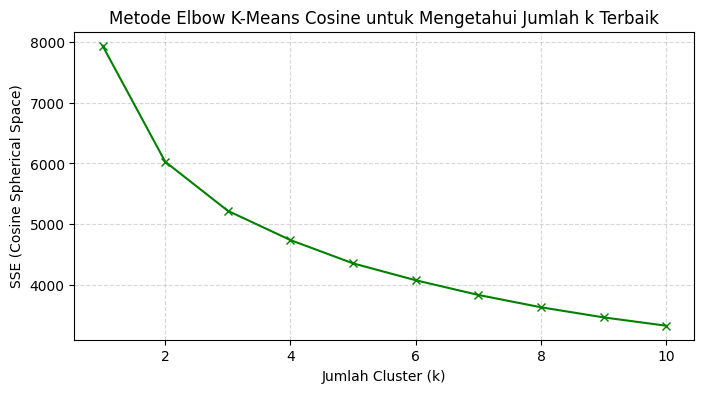

In [ ]:
from sklearn.preprocessing import normalize

# Normalisasi L2 data yang telah distandardisasi
X_norm = normalize(X, norm='l2')

sse_cosine = []
K = range(1, 11)

for k in K:
    kmean_c = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmean_c.fit(X_norm)
    sse_cosine.append(kmean_c.inertia_)

# Plotting Elbow
plt.figure(figsize=(8, 4))
plt.plot(K, sse_cosine, 'gx-')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('SSE (Cosine Spherical Space)')
plt.title('Metode Elbow K-Means Cosine untuk Mengetahui Jumlah k Terbaik')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### **6.2 Menampilkan Nilai SSE Setiap k (Cosine)**

In [ ]:
for k, nilai_sse in zip(K, sse_cosine):
    print(f'k = {k}, SSE = {nilai_sse:.2f}')

k = 1, SSE = 7943.65
k = 2, SSE = 6028.69
k = 3, SSE = 5218.22
k = 4, SSE = 4734.91
k = 5, SSE = 4350.53
k = 6, SSE = 4071.79
k = 7, SSE = 3829.37
k = 8, SSE = 3625.73
k = 9, SSE = 3458.68
k = 10, SSE = 3321.18


### **6.3 Evaluasi Jumlah Cluster Menggunakan Silhouette Score (Cosine)**

In [ ]:
for k in range(2, 11):
    km_c = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km_c.fit_predict(X_norm)
    score = silhouette_score(X, labels, metric='cosine')
    print(f'k = {k}, silhouette (cosine) = {score:.4f}')

k = 2, silhouette (cosine) = 0.3738
k = 3, silhouette (cosine) = 0.3375
k = 4, silhouette (cosine) = 0.3194
k = 5, silhouette (cosine) = 0.3217
k = 6, silhouette (cosine) = 0.3087
k = 7, silhouette (cosine) = 0.3060
k = 8, silhouette (cosine) = 0.2887
k = 9, silhouette (cosine) = 0.2858
k = 10, silhouette (cosine) = 0.2895


### **6.4 Kesimpulan & Training Model Final (k = 2)**


In [ ]:
# Training model final dengan k optimal = 2
kmeans_cosine = KMeans(n_clusters=2, random_state=42, n_init=10)
labels_cosine = kmeans_cosine.fit_predict(X_norm)

sil_cosine = silhouette_score(X, labels_cosine, metric='cosine')
db_cosine = davies_bouldin_score(X, labels_cosine)

print("=== HASIL FINAL K-MEANS COSINE (k=2) ===")
print("Distribusi data per cluster :", np.bincount(labels_cosine))
print(f"Silhouette Score (Cosine)    : {sil_cosine:.4f}")
print(f"Davies-Bouldin Index         : {db_cosine:.4f}")

=== HASIL FINAL K-MEANS COSINE (k=2) ===
Distribusi data per cluster : [4446 3555]
Silhouette Score (Cosine)    : 0.3738
Davies-Bouldin Index         : 1.6371


Berdasarkan evaluasi Silhouette Score dengan metrik Cosine untuk $k = 2$ sampai $k = 10$, nilai tertinggi diperoleh pada $k = 2$ sebesar 0.3738. Ini membuktikan bahwa pembagian data menjadi 2 klaster merupakan konfigurasi paling optimal pada metrik Cosine.

---
# **VISUALISASI DAN PERBANDINGAN MODEL**

7.1 Visualisasi Persebaran Klaster Menggunakan PCA (2D)

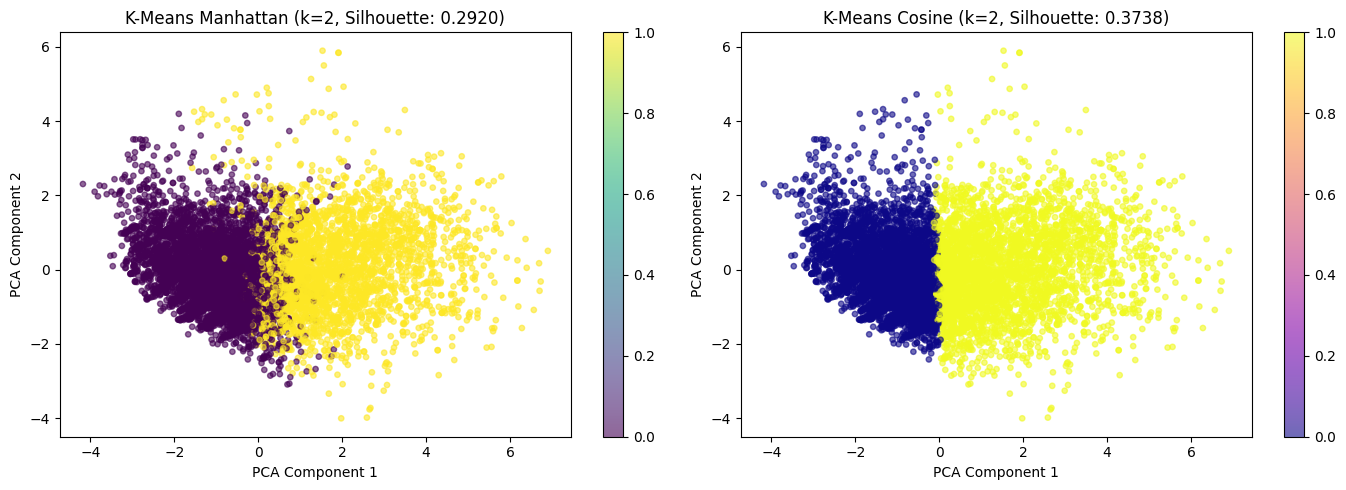

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot K-Means Manhattan
scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=labels_manhattan, cmap='viridis', alpha=0.6, s=15)
axes[0].set_title(f'K-Means Manhattan (k=2, Silhouette: {sil_manhattan:.4f})')
axes[0].set_xlabel('PCA Component 1')
axes[0].set_ylabel('PCA Component 2')
plt.colorbar(scatter1, ax=axes[0])

# Plot K-Means Cosine
scatter2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=labels_cosine, cmap='plasma', alpha=0.6, s=15)
axes[1].set_title(f'K-Means Cosine (k=2, Silhouette: {sil_cosine:.4f})')
axes[1].set_xlabel('PCA Component 1')
axes[1].set_ylabel('PCA Component 2')
plt.colorbar(scatter2, ax=axes[1])

plt.tight_layout()
plt.show()

7.2 Tabel Ringkasan Evaluasi Komparatif

In [ ]:
# Mengambil hasil Euclidean milik Nuril (k=2) sebagai pembanding
sil_euclidean = 0.2724
db_euclidean = davies_bouldin_score(X, KMeans(n_clusters=2, random_state=42).fit_predict(X))

df_perbandingan = pd.DataFrame({
    'Model K-Means': ['K-Means Euclidean (Nuril)', 'K-Means Manhattan (Hanif)', 'K-Means Cosine (Hanif)'],
    'Metrik Jarak': ['Euclidean (L2)', 'Manhattan (L1)', 'Cosine Distance'],
    'Cluster Optimal (k)': [2, 2, 2],
    'Silhouette Score': [sil_euclidean, sil_manhattan, sil_cosine],
    'Davies-Bouldin Index': [db_euclidean, db_manhattan, db_cosine]
})

print("==================== TABEL PERBANDINGAN MODEL K-MEANS ====================")
print(df_perbandingan.to_string(index=False))

==================== TABEL PERBANDINGAN MODEL K-MEANS ====================
            Model K-Means    Metrik Jarak  Cluster Optimal (k)  Silhouette Score  Davies-Bouldin Index
K-Means Euclidean (Nuril)  Euclidean (L2)                    2          0.272400              1.545718
K-Means Manhattan (Hanif)  Manhattan (L1)                    2          0.291961              1.647164
   K-Means Cosine (Hanif) Cosine Distance                    2          0.373807              1.637086


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score
)
import time

# **4. MENENTUKAN PARAMETER DBSCAN ([Naufal abid_244107020212])**

DBSCAN tidak memerlukan jumlah cluster (k) di awal. Parameter yang harus ditentukan adalah:
- **eps** : radius ketetanggaan (jarak Euclidean maksimum antar titik tetangga)
- **min_samples** : jumlah minimum titik dalam radius eps agar sebuah titik menjadi *core point*

### **4.1 Menentukan min_samples Awal**

Aturan umum: `min_samples = 2 × jumlah fitur`.

In [ ]:
min_samples_awal = 2 * df.shape[1]
print("Jumlah fitur         :", df.shape[1])
print("min_samples awal     :", min_samples_awal)

Jumlah fitur         : 8
min_samples awal     : 16


### **4.2 K-Distance Graph (Menentukan eps)**

Untuk setiap titik dihitung jarak Euclidean ke tetangga ke-`min_samples`, lalu diurutkan. Nilai `eps` yang baik berada di titik "siku" (kenaikan tajam) pada grafik.

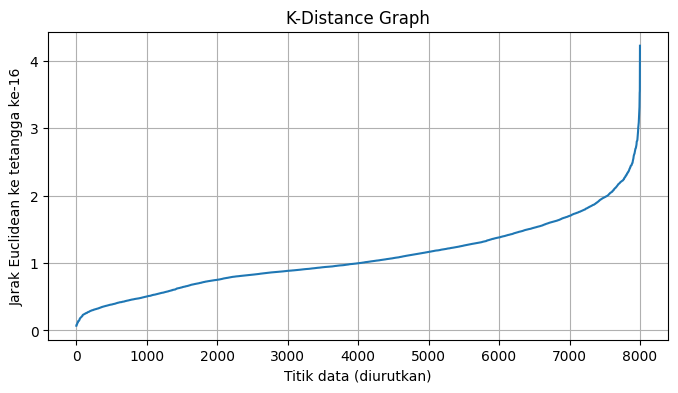

In [ ]:
nn = NearestNeighbors(
    n_neighbors=min_samples_awal,
    metric='euclidean'
)
nn.fit(df)

jarak, _ = nn.kneighbors(df)
k_distance = np.sort(jarak[:, -1])

plt.figure(figsize=(8,4))
plt.plot(k_distance)
plt.xlabel('Titik data (diurutkan)')
plt.ylabel(f'Jarak Euclidean ke tetangga ke-{min_samples_awal}')
plt.title('K-Distance Graph')
plt.grid(True)
plt.show()

### **4.3 Pencarian Kombinasi eps dan min_samples (Grid Search)**

Setiap kombinasi dievaluasi dengan Silhouette Score. Titik noise (label -1) tidak dihitung dalam Silhouette, dan kombinasi hanya dianggap valid jika menghasilkan minimal 2 cluster.

In [ ]:
list_min_samples = [min_samples_awal // 2, min_samples_awal, min_samples_awal * 2]
list_eps = np.round(np.arange(0.5, 3.01, 0.25), 2)

hasil_grid = []

for ms in list_min_samples:
    for eps in list_eps:

        model = DBSCAN(
            eps=eps,
            min_samples=ms,
            metric='euclidean'
        )
        labels = model.fit_predict(df)

        n_cluster = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = int(np.sum(labels == -1))

        if n_cluster >= 2:
            mask = labels != -1
            sil = silhouette_score(df[mask], labels[mask])
        else:
            sil = np.nan

        hasil_grid.append({
            'min_samples': ms,
            'eps': eps,
            'n_cluster': n_cluster,
            'n_noise': n_noise,
            'noise_ratio (%)': round(n_noise / len(df) * 100, 2),
            'silhouette': sil
        })

df_grid = pd.DataFrame(hasil_grid)
df_grid

,min_samples,eps,n_cluster,n_noise,noise_ratio (%),silhouette
0,8,0.50,101,5578,69.72,0.384169
1,8,0.75,81,4024,50.29,-0.052474
2,8,1.00,9,2103,26.28,0.046923
3,8,1.25,9,1122,14.02,0.062309
4,8,1.50,3,488,6.10,0.323617
5,8,1.75,1,190,2.37,NaN
6,8,2.00,1,71,0.89,NaN
7,8,2.25,1,22,0.27,NaN
8,8,2.50,1,10,0.12,NaN
9,8,2.75,1,2,0.02,NaN


### **4.4 Memilih Parameter Terbaik**

Kriteria: jumlah cluster ≥ 2, proporsi noise ≤ 20%, dan Silhouette Score tertinggi. Jika tidak ada yang memenuhi batas noise, batas tersebut diabaikan.

In [ ]:
valid = df_grid.dropna(subset=['silhouette'])
valid_noise = valid[valid['noise_ratio (%)'] <= 20]

kandidat = valid_noise if len(valid_noise) > 0 else valid
terbaik = kandidat.loc[kandidat['silhouette'].idxmax()]

best_eps = float(terbaik['eps'])
best_min_samples = int(terbaik['min_samples'])

print("Parameter terbaik:")
print(terbaik)
print()
print("eps         :", best_eps)
print("min_samples :", best_min_samples)

Parameter terbaik:
min_samples          8.000000
eps                  1.500000
n_cluster            3.000000
n_noise            488.000000
noise_ratio (%)      6.100000
silhouette           0.323617
Name: 4, dtype: float64

eps         : 1.5
min_samples : 8


Parameter di atas dipilih berdasarkan Silhouette Score tertinggi dengan batas noise 20%. Nilai `best_eps` dan `best_min_samples` dapat disesuaikan manual dengan melihat K-Distance Graph (4.2) dan tabel grid search (4.3).

# **5. DBSCAN - EUCLIDEAN DISTANCE ([Naufal abid_244107020212])**

## **5.1 Visualisasi Data Awal**

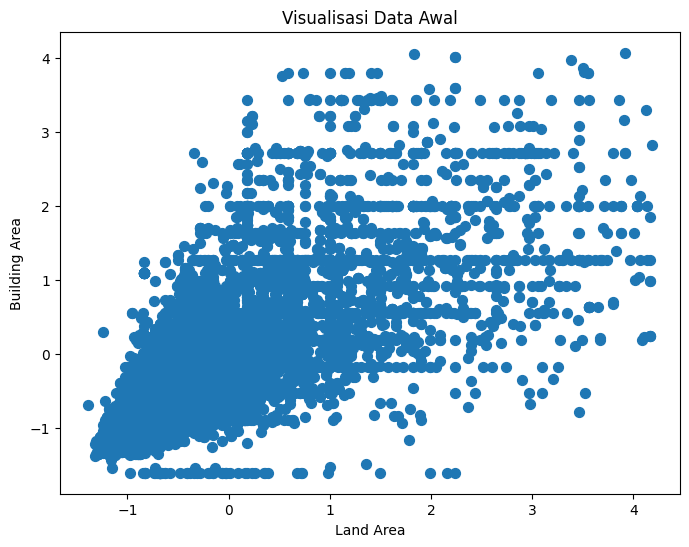

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    df['land_area'],
    df['building_area'],
    s=50
)

plt.xlabel('Land Area')
plt.ylabel('Building Area')
plt.title('Visualisasi Data Awal')

plt.show()

### **5.2 Membuat Model DBSCAN**

In [ ]:
# Inisiasi Model
cl_dbscan = DBSCAN(
    eps=best_eps,
    min_samples=best_min_samples,
    metric='euclidean'
)

# Fit dan Predict
y_dbscan = cl_dbscan.fit_predict(df)

n_cluster = len(set(y_dbscan)) - (1 if -1 in y_dbscan else 0)
n_noise = int(np.sum(y_dbscan == -1))

print("Jumlah cluster :", n_cluster)
print("Jumlah noise   :", n_noise, f"({n_noise/len(df)*100:.2f}%)")
print("Core points    :", len(cl_dbscan.core_sample_indices_))
print("Anggota per label:")
print(pd.Series(y_dbscan).value_counts().sort_index())

Jumlah cluster : 3
Jumlah noise   : 488 (6.10%)
Core points    : 6998
Anggota per label:
-1     488
 0    7491
 1       8
 2      14
Name: count, dtype: int64


### **5.3 Model DBSCAN Euclidean Distance (Manual)**

Algoritma: (1) hitung tetangga setiap titik dalam radius `eps` dengan jarak Euclidean, (2) titik dengan jumlah tetangga ≥ `min_samples` menjadi *core point*, (3) cluster dibentuk dengan memperluas dari core point ke seluruh titik yang *density-reachable*, (4) titik yang tidak terjangkau diberi label -1 (noise).

In [ ]:
# ==========================
# DBSCAN MANUAL
# ==========================

X = df.values
n = len(X)

eps = best_eps
min_pts = best_min_samples

# ==========================
# HITUNG JARAK EUCLIDEAN & CARI TETANGGA
# ==========================
start_manual = time.time()

neighbors = []
for i in range(n):
    # jarak Euclidean titik i ke semua titik: sqrt(sum((xi - xj)^2))
    jarak_i = np.sqrt(np.sum((X - X[i]) ** 2, axis=1))
    neighbors.append(np.where(jarak_i <= eps)[0])   # termasuk titik itu sendiri

# ==========================
# TENTUKAN CORE POINT
# ==========================
is_core = np.array([len(nb) >= min_pts for nb in neighbors])

# ==========================
# BENTUK CLUSTER
# ==========================
labels_manual = np.full(n, -1)   # -1 = noise / belum terklaster
cluster_id = 0

for i in range(n):

    # lewati jika bukan core point atau sudah punya cluster
    if not is_core[i] or labels_manual[i] != -1:
        continue

    # mulai cluster baru dari core point i
    labels_manual[i] = cluster_id
    queue = [i]

    while queue:
        p = queue.pop(0)

        # hanya core point yang boleh memperluas cluster
        if not is_core[p]:
            continue

        for q in neighbors[p]:
            if labels_manual[q] == -1:
                labels_manual[q] = cluster_id
                queue.append(q)

    cluster_id += 1

end_manual = time.time()

# Hasil akhir
y_dbscan_manual = labels_manual

n_cluster_manual = cluster_id
n_noise_manual = int(np.sum(y_dbscan_manual == -1))

print("Jumlah cluster :", n_cluster_manual)
print("Jumlah noise   :", n_noise_manual, f"({n_noise_manual/n*100:.2f}%)")
print("Core points    :", int(is_core.sum()))

Jumlah cluster : 3
Jumlah noise   : 488 (6.10%)
Core points    : 6998


### **5.4 Visualisasi Hasil Clustering**

Titik hitam (silang) adalah noise. DBSCAN tidak memiliki centroid, sehingga yang ditandai adalah *core point*.

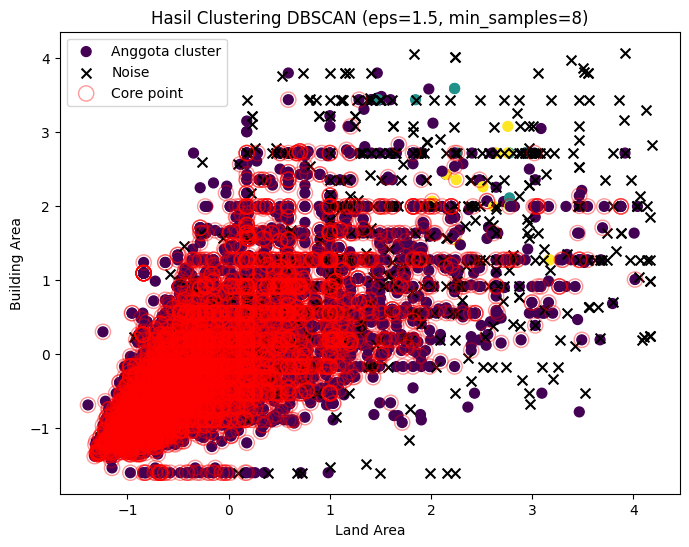

In [ ]:
plt.figure(figsize=(8,6))

noise = y_dbscan == -1
core = np.zeros(len(df), dtype=bool)
core[cl_dbscan.core_sample_indices_] = True

# Titik anggota cluster
plt.scatter(
    df['land_area'][~noise],
    df['building_area'][~noise],
    c=y_dbscan[~noise],
    s=50,
    cmap='viridis',
    label='Anggota cluster'
)

# Noise
plt.scatter(
    df['land_area'][noise],
    df['building_area'][noise],
    c='black',
    marker='x',
    s=50,
    label='Noise'
)

# Core point
plt.scatter(
    df['land_area'][core],
    df['building_area'][core],
    facecolors='none',
    edgecolors='red',
    s=120,
    alpha=0.4,
    label='Core point'
)

plt.xlabel('Land Area')
plt.ylabel('Building Area')
plt.title(f'Hasil Clustering DBSCAN (eps={best_eps}, min_samples={best_min_samples})')
plt.legend()
plt.show()

### **5.5 Visualisasi Hasil Clustering (Manual)**

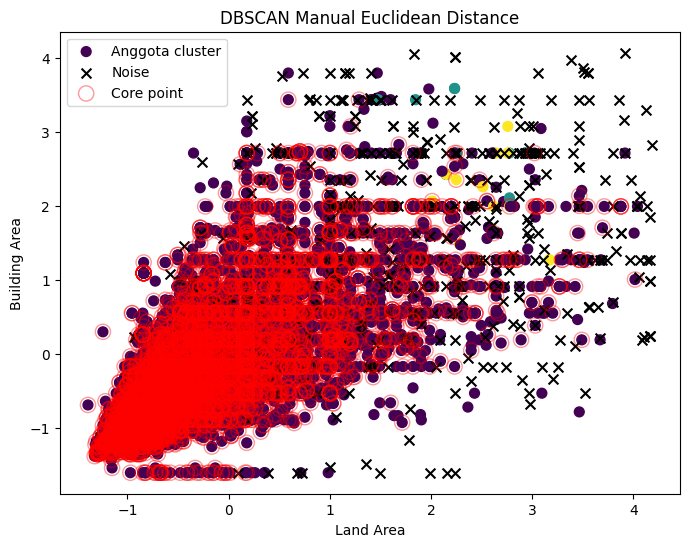

In [ ]:
plt.figure(figsize=(8,6))

noise_m = y_dbscan_manual == -1

plt.scatter(
    df['land_area'][~noise_m],
    df['building_area'][~noise_m],
    c=y_dbscan_manual[~noise_m],
    s=50,
    cmap='viridis',
    label='Anggota cluster'
)

plt.scatter(
    df['land_area'][noise_m],
    df['building_area'][noise_m],
    c='black',
    marker='x',
    s=50,
    label='Noise'
)

plt.scatter(
    df['land_area'][is_core],
    df['building_area'][is_core],
    facecolors='none',
    edgecolors='red',
    s=120,
    alpha=0.4,
    label='Core point'
)

plt.xlabel('Land Area')
plt.ylabel('Building Area')
plt.title('DBSCAN Manual Euclidean Distance')
plt.legend()
plt.show()

### **5.6 Evaluasi**

Metrik evaluasi dihitung **tanpa titik noise** (label -1). Metrik SSE dan jumlah iterasi pada K-Means tidak berlaku untuk DBSCAN, sehingga diganti dengan jumlah cluster, jumlah noise, dan jumlah core point.

In [ ]:
# Mengukur waktu eksekusi
start_time = time.time()

cl_dbscan = DBSCAN(
    eps=best_eps,
    min_samples=best_min_samples,
    metric='euclidean'
)

y_dbscan = cl_dbscan.fit_predict(df)

end_time = time.time()

In [ ]:
# Ambil Nilai Evaluasi (tanpa noise)
mask = y_dbscan != -1
n_cluster = len(set(y_dbscan[mask]))

if n_cluster >= 2:
    silhouette = silhouette_score(df[mask], y_dbscan[mask])
    dbi = davies_bouldin_score(df[mask], y_dbscan[mask])
    chi = calinski_harabasz_score(df[mask], y_dbscan[mask])
else:
    silhouette = dbi = chi = np.nan
    print("Peringatan: cluster < 2, metrik tidak dapat dihitung.")

execution_time = end_time - start_time
n_noise = int(np.sum(y_dbscan == -1))
n_core = len(cl_dbscan.core_sample_indices_)

In [ ]:
hasil = pd.DataFrame({
    'Distance Metric': ['DBSCAN - Euclidean Distance'],
    'eps': [best_eps],
    'min_samples': [best_min_samples],
    'Jumlah Cluster': [n_cluster],
    'Jumlah Noise': [n_noise],
    'Noise (%)': [round(n_noise / len(df) * 100, 2)],
    'Core Points': [n_core],
    'Silhouette Score (↑)': [round(silhouette, 4)],
    'Davies–Bouldin Index (↓)': [round(dbi, 4)],
    'Calinski–Harabasz Index (↑)': [round(chi, 2)],
    'Execution Time (s) (↓)': [round(execution_time, 5)]
})

print("="*80)
print("TABEL EVALUASI DBSCAN EUCLIDEAN")
print("="*80)

print(hasil.T.to_string(header=False))

TABEL EVALUASI DBSCAN EUCLIDEAN
Distance Metric              DBSCAN - Euclidean Distance
eps                                                  1.5
min_samples                                            8
Jumlah Cluster                                         3
Jumlah Noise                                         488
Noise (%)                                            6.1
Core Points                                         6998
Silhouette Score (↑)                              0.3236
Davies–Bouldin Index (↓)                          0.7124
Calinski–Harabasz Index (↑)                        43.64
Execution Time (s) (↓)                           0.78329


### **Evaluasi Manual**

In [ ]:
mask_m = y_dbscan_manual != -1
n_cluster_m = len(set(y_dbscan_manual[mask_m]))

if n_cluster_m >= 2:
    sil_m = silhouette_score(df[mask_m], y_dbscan_manual[mask_m])
    dbi_m = davies_bouldin_score(df[mask_m], y_dbscan_manual[mask_m])
    chi_m = calinski_harabasz_score(df[mask_m], y_dbscan_manual[mask_m])
else:
    sil_m = dbi_m = chi_m = np.nan

hasil_manual = pd.DataFrame({
    'Distance Metric': ['DBSCAN Manual - Euclidean Distance'],
    'eps': [best_eps],
    'min_samples': [best_min_samples],
    'Jumlah Cluster': [n_cluster_m],
    'Jumlah Noise': [n_noise_manual],
    'Noise (%)': [round(n_noise_manual / len(df) * 100, 2)],
    'Core Points': [int(is_core.sum())],
    'Silhouette Score (↑)': [round(sil_m, 4)],
    'Davies–Bouldin Index (↓)': [round(dbi_m, 4)],
    'Calinski–Harabasz Index (↑)': [round(chi_m, 2)],
    'Execution Time (s) (↓)': [round(end_manual - start_manual, 5)]
})

print("="*80)
print("TABEL EVALUASI DBSCAN MANUAL EUCLIDEAN")
print("="*80)

print(hasil_manual.T.to_string(header=False))

TABEL EVALUASI DBSCAN MANUAL EUCLIDEAN
Distance Metric              DBSCAN Manual - Euclidean Distance
eps                                                         1.5
min_samples                                                   8
Jumlah Cluster                                                3
Jumlah Noise                                                488
Noise (%)                                                   6.1
Core Points                                                6998
Silhouette Score (↑)                                     0.3236
Davies–Bouldin Index (↓)                                 0.7124
Calinski–Harabasz Index (↑)                               43.64
Execution Time (s) (↓)                                  1.13852


# **6. MENENTUKAN PARAMETER DBSCAN (Jasmine_244107020119)**

### **6.1 Menentukan Nilai min_samples**

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

min_samples_dbscan = 2 * df.shape[1]

print("Jumlah fitur       :", df.shape[1])
print("Nilai min_samples  :", min_samples_dbscan)

Jumlah fitur       : 8
Nilai min_samples  : 16


### **6.2 K-Distance Graph (Manhattan Distance)**

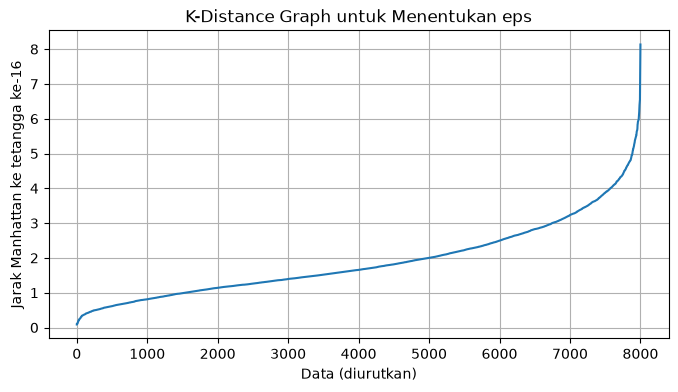

In [ ]:
nn = NearestNeighbors(
    n_neighbors=min_samples_dbscan,
    metric='manhattan'
)
nn.fit(df)

jarak_nn, _ = nn.kneighbors(df)

k_distance = np.sort(jarak_nn[:, -1])

plt.figure(figsize=(8,4))
plt.plot(k_distance)
plt.xlabel('Data (diurutkan)')
plt.ylabel(f'Jarak Manhattan ke tetangga ke-{min_samples_dbscan}')
plt.title('K-Distance Graph untuk Menentukan eps')
plt.grid(True)
plt.show()

### **6.3 Evaluasi Beberapa Nilai eps**

In [ ]:
daftar_eps = [1.5, 2.0, 2.5, 3.0, 3.5, 4.0]

for eps_coba in daftar_eps:

    model_coba = DBSCAN(
        eps=eps_coba,
        min_samples=min_samples_dbscan,
        metric='manhattan'
    )

    label_coba = model_coba.fit_predict(df)

    jumlah_cluster = len(set(label_coba)) - (1 if -1 in label_coba else 0)
    jumlah_noise = np.sum(label_coba == -1)

    if jumlah_cluster >= 2:
        mask = label_coba != -1
        skor = silhouette_score(
            df[mask],
            label_coba[mask],
            metric='manhattan'
        )
        print(f'eps = {eps_coba}, cluster = {jumlah_cluster}, noise = {jumlah_noise}, silhouette = {skor:.4f}')
    else:
        print(f'eps = {eps_coba}, cluster = {jumlah_cluster}, noise = {jumlah_noise}, silhouette = tidak dapat dihitung')

eps = 1.5, cluster = 2, noise = 3115, silhouette = -0.0562
eps = 2.0, cluster = 3, noise = 1829, silhouette = 0.2340
eps = 2.5, cluster = 2, noise = 1020, silhouette = 0.2876
eps = 3.0, cluster = 1, noise = 481, silhouette = tidak dapat dihitung
eps = 3.5, cluster = 1, noise = 204, silhouette = tidak dapat dihitung
eps = 4.0, cluster = 1, noise = 80, silhouette = tidak dapat dihitung


# **7. DBSCAN - MANHATTAN DISTANCE (Jasmine_244107020119)**

## **7.1 Visualisasi Data Awal**

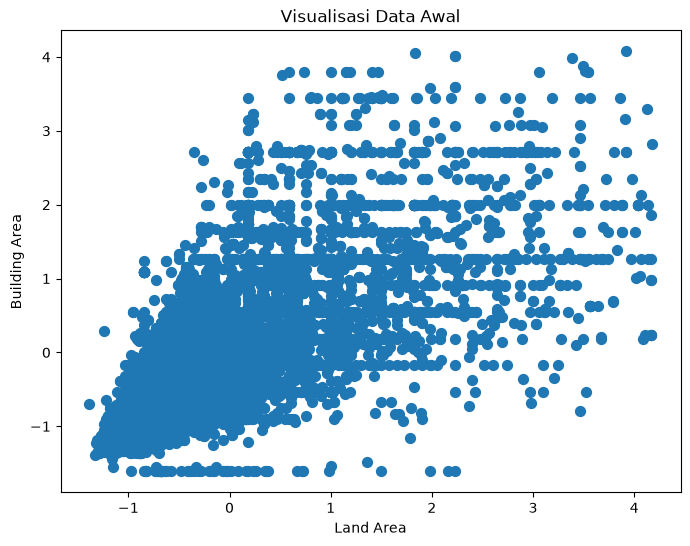

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    df['land_area'],
    df['building_area'],
    s=50
)

plt.xlabel('Land Area')
plt.ylabel('Building Area')
plt.title('Visualisasi Data Awal')

plt.show()

### **7.2 Model DBSCAN Manhattan (Library)**

In [ ]:
eps_dbscan = 2.5
min_samples_dbscan = 2 * df.shape[1]

start_time_dbscan_library = time.time()

cl_dbscan = DBSCAN(
    eps=eps_dbscan,
    min_samples=min_samples_dbscan,
    metric='manhattan'
)

y_dbscan = cl_dbscan.fit_predict(df)

end_time_dbscan_library = time.time()

print("Jumlah cluster :", len(set(y_dbscan)) - (1 if -1 in y_dbscan else 0))
print("Jumlah noise   :", np.sum(y_dbscan == -1))

Jumlah cluster : 2
Jumlah noise   : 1020


### **7.3 Model DBSCAN Manhattan Distance (Manual)**

In [ ]:
start_time_dbscan_manual = time.time()

X_db = df.values
n_data = len(X_db)

neighbors = []

for i in range(n_data):

    jarak_manhattan = np.sum(np.abs(X_db - X_db[i]), axis=1)

    tetangga = np.where(jarak_manhattan <= eps_dbscan)[0]

    neighbors.append(tetangga)


is_core = np.array([len(tetangga) >= min_samples_dbscan for tetangga in neighbors])

y_dbscan_manual = np.full(n_data, -1)

cluster_id = 0

for i in range(n_data):

    if y_dbscan_manual[i] != -1 or not is_core[i]:
        continue

    stack = [i]

    while stack:

        titik = stack.pop()

        if y_dbscan_manual[titik] == -1:

            y_dbscan_manual[titik] = cluster_id

            if is_core[titik]:

                for tetangga in neighbors[titik]:

                    if y_dbscan_manual[tetangga] == -1:
                        stack.append(tetangga)

    cluster_id += 1

end_time_dbscan_manual = time.time()

print("Jumlah core point :", np.sum(is_core))
print("Jumlah cluster    :", cluster_id)
print("Jumlah noise      :", np.sum(y_dbscan_manual == -1))
print("Hasil sama dengan library :", np.array_equal(y_dbscan, y_dbscan_manual))

Jumlah core point : 6005
Jumlah cluster    : 2
Jumlah noise      : 1020
Hasil sama dengan library : True


### **7.4 Visualisasi Hasil Clustering**

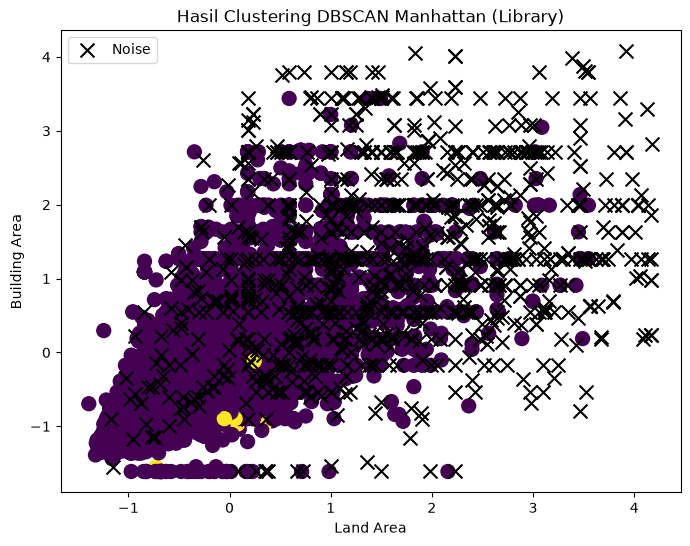

In [ ]:
plt.figure(figsize=(8,6))

mask_cluster = y_dbscan != -1

plt.scatter(
    df['land_area'][mask_cluster],
    df['building_area'][mask_cluster],
    s=100,
    c=y_dbscan[mask_cluster]
)

plt.scatter(
    df['land_area'][~mask_cluster],
    df['building_area'][~mask_cluster],
    s=100,
    c='black',
    marker='x',
    label='Noise'
)

plt.xlabel('Land Area')
plt.ylabel('Building Area')
plt.title('Hasil Clustering DBSCAN Manhattan (Library)')
plt.legend()

plt.show()

### **7.5 Visualisasi Hasil Clustering (Manual)**

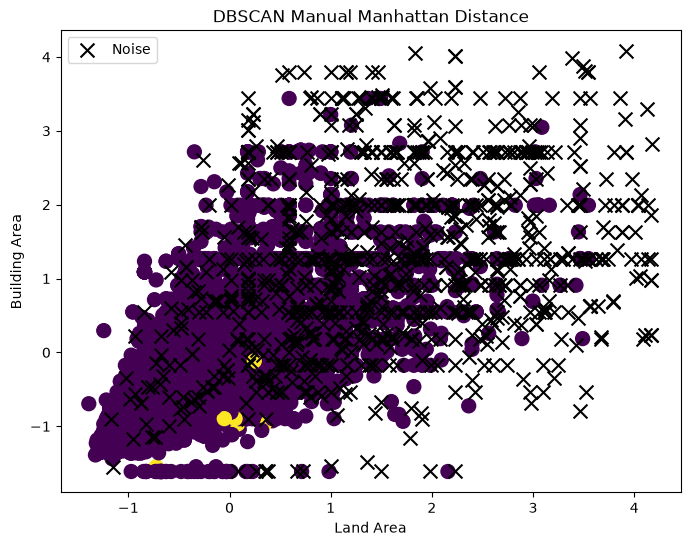

In [ ]:
plt.figure(figsize=(8,6))

mask_cluster_manual = y_dbscan_manual != -1

plt.scatter(
    df['land_area'][mask_cluster_manual],
    df['building_area'][mask_cluster_manual],
    s=100,
    c=y_dbscan_manual[mask_cluster_manual]
)

plt.scatter(
    df['land_area'][~mask_cluster_manual],
    df['building_area'][~mask_cluster_manual],
    s=100,
    c='black',
    marker='x',
    label='Noise'
)

plt.xlabel('Land Area')
plt.ylabel('Building Area')
plt.title('DBSCAN Manual Manhattan Distance')
plt.legend()

plt.show()

### **7.6 Evaluasi DBSCAN (Library)**

In [ ]:
mask_eval = y_dbscan != -1

silhouette_dbscan = silhouette_score(
    df[mask_eval],
    y_dbscan[mask_eval],
    metric='manhattan'
)

dbi_dbscan = davies_bouldin_score(df[mask_eval], y_dbscan[mask_eval])

chi_dbscan = calinski_harabasz_score(df[mask_eval], y_dbscan[mask_eval])

execution_time_dbscan = end_time_dbscan_library - start_time_dbscan_library

jumlah_cluster_dbscan = len(set(y_dbscan)) - (1 if -1 in y_dbscan else 0)

jumlah_noise_dbscan = np.sum(y_dbscan == -1)

### **7.7 Evaluasi DBSCAN (Manual)**

In [ ]:

mask_eval_manual = y_dbscan_manual != -1

silhouette_dbscan_manual = silhouette_score(
    df[mask_eval_manual],
    y_dbscan_manual[mask_eval_manual],
    metric='manhattan'
)

dbi_dbscan_manual = davies_bouldin_score(df[mask_eval_manual], y_dbscan_manual[mask_eval_manual])

chi_dbscan_manual = calinski_harabasz_score(df[mask_eval_manual], y_dbscan_manual[mask_eval_manual])

execution_time_dbscan_manual = end_time_dbscan_manual - start_time_dbscan_manual

jumlah_cluster_dbscan_manual = cluster_id

jumlah_noise_dbscan_manual = np.sum(y_dbscan_manual == -1)

In [ ]:
hasil_dbscan = pd.DataFrame({
    'Metode': ['DBSCAN Library', 'DBSCAN Manual'],
    'Silhouette': [silhouette_dbscan, silhouette_dbscan_manual],
    'DBI': [dbi_dbscan, dbi_dbscan_manual],
    'CHI': [chi_dbscan, chi_dbscan_manual],
    'Execution Time': [
        execution_time_dbscan,
        execution_time_dbscan_manual
    ],
    'Jumlah Cluster': [
        jumlah_cluster_dbscan,
        jumlah_cluster_dbscan_manual
    ],
    'Jumlah Noise': [
        jumlah_noise_dbscan,
        jumlah_noise_dbscan_manual
    ]
})

print("=" * 80)
print("TABEL EVALUASI DBSCAN MANHATTAN")
print("=" * 80)

print(hasil_dbscan.to_string(index=False))

TABEL EVALUASI DBSCAN MANHATTAN
        Metode  Silhouette      DBI       CHI  Execution Time  Jumlah Cluster  Jumlah Noise
DBSCAN Library    0.287648 0.869643 77.939548        0.952256               2          1020
 DBSCAN Manual    0.287648 0.869643 77.939548        1.543751               2          1020


In [ ]:
variabel_cek = [
    'y_dbscan_manual',
    'cluster_id',
    'end_time_dbscan_manual',
    'silhouette_dbscan_manual',
    'dbi_dbscan_manual',
    'chi_dbscan_manual',
    'execution_time_dbscan_manual',
    'jumlah_cluster_dbscan_manual',
    'jumlah_noise_dbscan_manual'
]

for v in variabel_cek:
    print(f"{v:35s} : {'ADA' if v in globals() else 'BELUM ADA'}")

y_dbscan_manual                     : ADA
cluster_id                          : ADA
end_time_dbscan_manual              : ADA
silhouette_dbscan_manual            : ADA
dbi_dbscan_manual                   : ADA
chi_dbscan_manual                   : ADA
execution_time_dbscan_manual        : ADA
jumlah_cluster_dbscan_manual        : ADA
jumlah_noise_dbscan_manual          : ADA


# **8. DBSCAN - COSINE (Nurfinka Lailasari_244107020211)**

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import time

X = df.values   # data hasil standarisasi
min_samples_awal = 16   # 2 x jumlah fitur (8 fitur)

K-distance plot

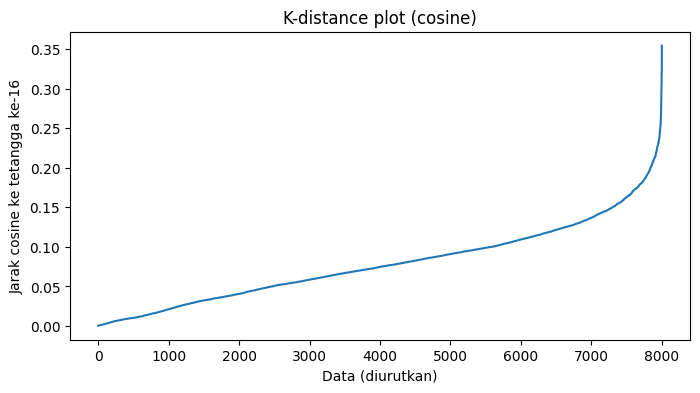

Persentil 50/70/80/90/95: [0.0747 0.1003 0.1189 0.1452 0.1715]


In [ ]:
nn = NearestNeighbors(n_neighbors=min_samples_awal, metric='cosine').fit(X)
dist, _ = nn.kneighbors(X)
k_dist = np.sort(dist[:, -1])

plt.figure(figsize=(8, 4))
plt.plot(k_dist)
plt.xlabel('Data (diurutkan)')
plt.ylabel(f'Jarak cosine ke tetangga ke-{min_samples_awal}')
plt.title('K-distance plot (cosine)')
plt.show()

print('Persentil 50/70/80/90/95:', np.percentile(k_dist, [50, 70, 80, 90, 95]).round(4))

**Eksperimen eps dan min_samples**

In [ ]:
persentil_list = [50, 70, 80, 90, 95]
ms_list = [8, 16, 32]

baris = []
for p in persentil_list:
    eps = float(np.percentile(k_dist, p))
    for ms in ms_list:
        lab = DBSCAN(eps=eps, min_samples=ms, metric='cosine').fit_predict(X)
        mask = lab != -1
        n_cl = len(set(lab[mask]))
        if n_cl >= 2:
            sil = silhouette_score(X[mask], lab[mask], metric='cosine',
                                   sample_size=min(3000, int(mask.sum())), random_state=42)
        else:
            sil = np.nan
        baris.append({'eps': round(eps, 4), 'min_samples': ms, 'Klaster': n_cl,
                      'Noise': int((~mask).sum()), 'Noise (%)': round(100 * (~mask).mean(), 1),
                      'Silhouette': round(sil, 3)})

grid_cosine = pd.DataFrame(baris)
grid_cosine

,eps,min_samples,Klaster,Noise,Noise (%),Silhouette
0,0.0747,8,13,1110,13.9,-0.544
1,0.0747,16,2,2285,28.6,-0.022
2,0.0747,32,5,3666,45.8,0.263
3,0.1003,8,2,387,4.8,-0.046
4,0.1003,16,2,787,9.8,-0.014
5,0.1003,32,1,1804,22.5,NaN
6,0.1189,8,3,159,2.0,-0.056
7,0.1189,16,1,384,4.8,NaN
8,0.1189,32,1,987,12.3,NaN
9,0.1452,8,1,44,0.5,NaN


**Pilih parameter dan model final**

In [ ]:
# Pilih otomatis: klaster >= 2, noise <= 30%, Silhouette tertinggi
kandidat = grid_cosine[(grid_cosine['Klaster'] >= 2) & (grid_cosine['Noise (%)'] <= 30)]
if len(kandidat) > 0:
    pilih = kandidat.sort_values('Silhouette', ascending=False).iloc[0]
    eps_final, ms_final = float(pilih['eps']), int(pilih['min_samples'])
else:
    eps_final, ms_final = float(np.percentile(k_dist, 90)), 16

# Atur manual bila perlu, contoh:
# eps_final, ms_final = 0.12, 16

start_time_dbscan = time.time()
db_cos = DBSCAN(eps=eps_final, min_samples=ms_final, metric='cosine')
y_dbscan = db_cos.fit_predict(X)
end_time_dbscan = time.time()

n_clusters_ = len(set(y_dbscan)) - (1 if -1 in y_dbscan else 0)
n_noise_ = list(y_dbscan).count(-1)

print(f'eps = {eps_final}, min_samples = {ms_final}')
print('Jumlah klaster:', n_clusters_)
print('Jumlah noise  :', n_noise_)
print('Anggota per label (-1 = noise):', dict(zip(*np.unique(y_dbscan, return_counts=True))))

eps = 0.1003, min_samples = 16
Jumlah klaster: 2
Jumlah noise  : 787
Anggota per label (-1 = noise): {np.int64(-1): np.int64(787), np.int64(0): np.int64(7201), np.int64(1): np.int64(13)}


**Visualisasi**

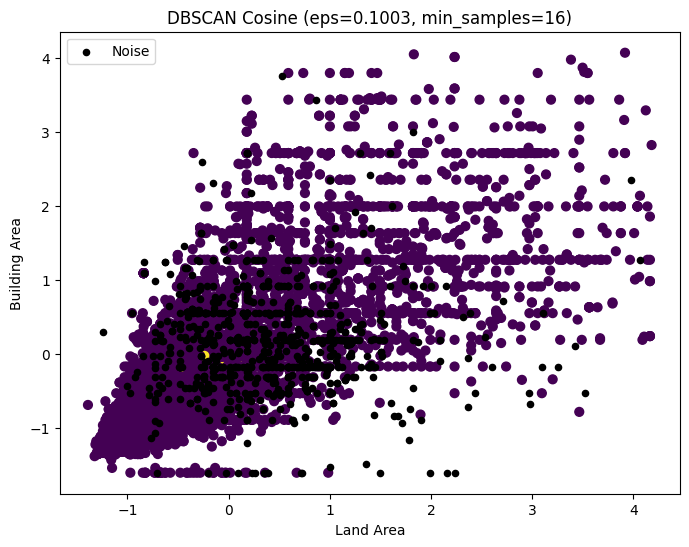

In [ ]:
noise = y_dbscan == -1

plt.figure(figsize=(8, 6))
plt.scatter(df['land_area'][~noise], df['building_area'][~noise],
            c=y_dbscan[~noise], s=40, cmap='viridis')
plt.scatter(df['land_area'][noise], df['building_area'][noise],
            c='black', s=20, label='Noise')
plt.xlabel('Land Area')
plt.ylabel('Building Area')
plt.title(f'DBSCAN Cosine (eps={eps_final}, min_samples={ms_final})')
plt.legend()
plt.show()

**Evaluasi**

In [ ]:
mask = y_dbscan != -1

if len(set(y_dbscan[mask])) >= 2:
    sil_cos = silhouette_score(X[mask], y_dbscan[mask], metric='cosine')
    sil_euc = silhouette_score(X[mask], y_dbscan[mask])
    dbi = davies_bouldin_score(X[mask], y_dbscan[mask])
    chi = calinski_harabasz_score(X[mask], y_dbscan[mask])
else:
    sil_cos = sil_euc = dbi = chi = np.nan

hasil_dbscan_cosine = pd.DataFrame({
    'Metode': ['DBSCAN Cosine'],
    'eps': [eps_final],
    'min_samples': [ms_final],
    'Klaster': [n_clusters_],
    'Noise': [n_noise_],
    'Silhouette (cosine)': [sil_cos],
    'Silhouette (euclidean)': [sil_euc],
    'DBI': [dbi],
    'CHI': [chi],
    'Execution Time': [end_time_dbscan - start_time_dbscan],
})

print("=" * 80)
print("TABEL EVALUASI DBSCAN COSINE (tanpa titik noise)")
print("=" * 80)
print(hasil_dbscan_cosine.to_string(index=False))

TABEL EVALUASI DBSCAN COSINE (tanpa titik noise)
       Metode    eps  min_samples  Klaster  Noise  Silhouette (cosine)  Silhouette (euclidean)      DBI      CHI  Execution Time
DBSCAN Cosine 0.1003           16        2    787            -0.015765               -0.215476 2.663597 2.236907        0.834312


---
## 1. Tabel Perbandingan Seluruh Metrik

| Metode | eps | min_samples | Jumlah Cluster | Jumlah Noise | Noise (%) | Core Points | Silhouette Score (↑) | Davies–Bouldin Index (↓) | Calinski–Harabasz Index (↑) | Execution Time (s) (↓) |
|---|---|---|---|---|---|---|---|---|---|---|
| K-Means Euclidean | - | - | 2 | 0 | 0 | - | 0.2724 | 1.5457 | 2902.13 | 0.0102 |
| K-Means Manhattan | - | - | 2 | 0 | 0 | - | 0.2920 | 1.6472 | - | - |
| K-Means Cosine | - | - | 2 | 0 | 0 | - | 0.3738 | 1.6371 | - | - |
| DBSCAN Euclidean | 1.5 | 8 | 3 | 488 | 6.10 | 6998 | 0.3236 | 0.7124 | 43.64 | 0.7833 |
| DBSCAN Manhattan | 2.5 | 16 | 2 | 1020 | 12.75 | 6005 | 0.2876 | 0.8696 | 77.94 | 0.9523 |
| DBSCAN Cosine | 0.1003 | 16 | 2 | 787 | 9.84 | - | -0.0158 | 2.6636 | 2.24 | 0.8343 |

Keterangan sumber angka:
* K-Means: tidak memakai eps, min_samples, maupun core point, sehingga kolom tersebut kosong. Silhouette K-Means Manhattan dan Cosine dihitung dengan metrik jaraknya sendiri. CHI dan Execution Time untuk K-Means Manhattan dan K-Means Cosine tidak dihitung di kode aslinya. Execution Time K-Means Euclidean adalah versi library.
* DBSCAN: semua metrik dihitung tanpa titik noise. Core Points untuk DBSCAN Cosine tidak dihitung di kode aslinya. Execution Time adalah versi library.
* Silhouette memakai metrik jaraknya masing-masing (Euclidean, Manhattan, Cosine), sedangkan DBI dan CHI selalu memakai jarak Euclidean.

## 2. Mengapa DBI DBSCAN yang Rendah Tidak Menjadikannya Terbaik

nilai DBI DBscan yang rendah tidak dapat dijadikan DBscan tersebut dinyatakan lebih baik, karena nilai tersebut dihasilkan dari cluster yang sangat tidak seimbang dan dari evaluasi yang mengecualikan titik noise, ditambah nilai CHI yang sangat rendah dan kualitas DBscan Cosine yang buruk di semua metrik, maka KMeans tetap menjadi metode yang lebih baik unggul dan lebih bisa diandalkan untuk melakukan clustering pada dataset rumah Jakarta ini, dengan KMeans Cosine sebagai model terbaik

## 3. Peringkat Keenam Metode

| Peringkat | Metode | Alasan utama |
|---|---|---|
| 1 | K-Means Cosine | Silhouette tertinggi (0.3738), cluster seimbang (4446 / 3555), tanpa noise, DBI 1.6371 |
| 2 | K-Means Euclidean | CHI tertinggi (2902.13), DBI terbaik di antara K-Means (1.5457), tercepat dan evaluasinya paling lengkap |
| 3 | K-Means Manhattan | Silhouette 0.2920 lebih baik dari Euclidean, tetapi DBI tertinggi di antara K-Means (1.6472) |
| 4 | DBSCAN Euclidean | Silhouette 0.3236 dan DBI 0.7124 baik, tetapi dua dari tiga cluster hanya berisi 8 dan 14 data, 488 data jadi noise |
| 5 | DBSCAN Manhattan | Noise terbanyak (12.75%), CHI rendah (77.94), Silhouette 0.2876 |
| 6 | DBSCAN Cosine | Silhouette negatif, DBI 2.6636, CHI 2.24, cluster kedua hanya 13 data |

## 4. Kesimpulan Akhir

Model terbaik adalah KMeans Cosine (k = 2), karena model tersebut paling baik dalam memisahkan data dengan Silhouette Score tertinggi (0.3738). Model tersebut membagi data menjadi dua cluster yang cukup seimbang (4446 dan 3555 data), dan tidak ada satupun data yang dibuang sebagai noise. DBSCAN Euclidean dan DBSCAN Manhattan memang punya nilai DBI yang lebih kecil, tetapi nilai tersebut kurang bisa dipercaya karena data noise tidak ikut dihitung dan cluster yang terbentuk sangat tidak seimbang, misalnya pada DBSCAN Euclidean sebanyak 7491 dari 8001 data masuk ke satu cluster.

Untuk keterbatasan, CHI dan waktu proses (Execution Time) untuk KMeans Cosine dan KMeans Manhattan tidak dihitung di kode asli, sehingga keunggulan KMeans Cosine dinilai dari Silhouette, jumlah noise, dan keseimbangan cluster. Nilai DBI KMeans Cosine (1.6371) juga sedikit lebih tinggi daripada KMeans Euclidean (1.5457), dan Silhouette dihitung dengan metrik jarak yang berbeda-beda sehingga perbandingannya bersifat indikatif. Dibandingkan DBSCAN, KMeans Euclidean jauh lebih unggul pada CHI dan kecepatan. Maka dari itu, jika yang lebih dipentingkan adalah perhitungan jarak yang paling umum dipakai dan evaluasi yang lengkap, KMeans Euclidean adalah pilihan cadangan yang terbaik.